# Personal Loan Acceptance - Exploratory Data Analysis

This notebook performs basic exploratory data analysis (EDA) on the **Personal Loan Modeling** dataset.

### Dataset Schema & Structure Notes:
- **Total Raw Columns:** 14 columns
- **Identifier Column:** `ID` (row/customer identifier, to be removed during preprocessing)
- **Input Features (12):** `Age`, `Experience`, `Income`, `ZIP Code`, `Family`, `CCAvg`, `Education`, `Mortgage`, `Securities Account`, `CD Account`, `Online`, `CreditCard` (Note: `Experience` may contain negative values to clean)
- **Target Variable:** `Personal Loan` (0 = Did not accept, 1 = Accepted)

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load Dataset

In [11]:
# Locate dataset path (supports running notebook from root or notebooks/ directory)
data_path = '../data/Bank_Personal_Loan_Modelling.xlsx'
if not os.path.exists(data_path):
    data_path = 'data/Bank_Personal_Loan_Modelling.xlsx'

print(f"Loading data from: {data_path}")
df = pd.read_excel(data_path, sheet_name="Data")

Loading data from: ../data/Bank_Personal_Loan_Modelling.xlsx


## 2. Dataset Shape

In [12]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Shape: 5000 rows, 14 columns


## 3. Column Names

The raw dataset has 14 columns:
- **1 Identifier:** `ID` (will be removed later during preprocessing)
- **12 Input Features:** Customer demographic and financial attributes
- **1 Target:** `Personal Loan` (0 = Did not accept, 1 = Accepted)

In [13]:
print("All Column Names:")
for idx, col in enumerate(df.columns, 1):
    print(f"{idx:2d}. {col}")

All Column Names:
 1. ID
 2. Age
 3. Experience
 4. Income
 5. ZIP Code
 6. Family
 7. CCAvg
 8. Education
 9. Mortgage
10. Personal Loan
11. Securities Account
12. CD Account
13. Online
14. CreditCard


## 4. First 5 Rows

In [14]:
df.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


## 5. Data Types

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


## 6. Missing Values Check

In [16]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df

,Missing Values,Missing Percentage (%)
ID,0,0.0
Age,0,0.0
Experience,0,0.0
Income,0,0.0
ZIP Code,0,0.0
Family,0,0.0
CCAvg,0,0.0
Education,0,0.0
Mortgage,0,0.0
Personal Loan,0,0.0


## 7. Descriptive Statistics

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937913,1.747666,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## 8. Distribution of Personal Loan Target

In [18]:
target_counts = df['Personal Loan'].value_counts()
target_percentages = df['Personal Loan'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_percentages.round(2)
})
target_dist.index.name = 'Personal Loan'
print(target_dist)

               Count  Percentage (%)
Personal Loan                       
0               4520            90.4
1                480             9.6


## 9. Personal Loan Count Plot

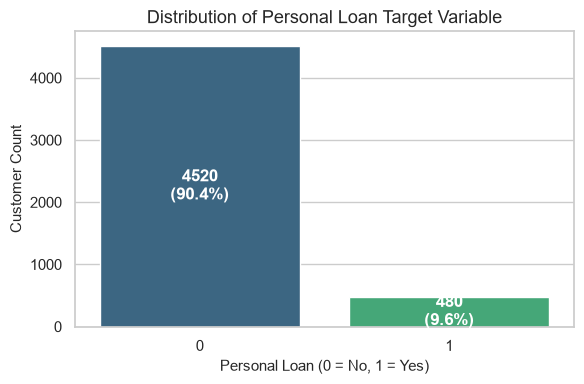

In [19]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Personal Loan', data=df, hue='Personal Loan', palette='viridis', legend=False)
plt.title('Distribution of Personal Loan Target Variable', fontsize=13)
plt.xlabel('Personal Loan (0 = No, 1 = Yes)', fontsize=11)
plt.ylabel('Customer Count', fontsize=11)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(f'{int(height)}\n({percentage})',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()